# 3.0 Model training - Ridge


## Imports


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

from recruit_restaurant_visitor_forecasting.config import (
    AIR_RESTAURANT_ID_COL,
    MODELS_DIR,
    VISIT_DATE_COL,
    DAY_OF_WEEK_COL,
)
from recruit_restaurant_visitor_forecasting.modeling.train import (
    load_data,
    prepare_features,
    create_model_pipeline,
    evaluate_model,
)
from recruit_restaurant_visitor_forecasting.plots import plot_daily_pred
from recruit_restaurant_visitor_forecasting.utils import merge_daily_pred

In [12]:
ALPHA = 1
USE_PCA = True
N_COMPONENTS = 25
CV_SPLITS = 5  

TEST_SIZE = 0.2  
CUTOFF_DATE = None  

MODEL_PATH = MODELS_DIR / "ridge_model.pkl"

## Load and prepare

In [13]:
features, labels = load_data()
print(f"Features shape: {features.shape}")
print(f"Labels shape: {labels.shape}")

Features shape: (271221, 49)
Labels shape: (271221,)


In [14]:
original_index = features.index.copy()
features = prepare_features(features)

labels = labels.loc[features.index].reset_index(drop=True)
features = features.reset_index(drop=True)

In [15]:
dates = features[VISIT_DATE_COL].copy()
restaurant_ids = features[AIR_RESTAURANT_ID_COL].copy() 

X = features.drop(columns=[AIR_RESTAURANT_ID_COL, VISIT_DATE_COL, DAY_OF_WEEK_COL])
y = labels

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, shuffle=False, random_state=42
)

split_idx = len(X_train)
train_dates = dates.iloc[:split_idx].reset_index(drop=True)
test_dates = dates.iloc[split_idx:].reset_index(drop=True)

print(f"Train set dates: {train_dates.min()} to {train_dates.max()}")
print(f"Test set dates: {test_dates.min()} to {test_dates.max()}")

Train set dates: 2016-02-01 00:00:00 to 2017-02-16 00:00:00
Test set dates: 2017-02-16 00:00:00 to 2017-04-22 00:00:00


In [17]:
model = create_model_pipeline(
    alpha=ALPHA,
    use_pca=USE_PCA,
    n_components=N_COMPONENTS,
)

## Cross-validation


In [18]:
cv_results = evaluate_model(model, X_train, y_train, cv_splits=CV_SPLITS)

print("Cross-validation results:")
print(f"  RMSE: {cv_results['rmse_mean']:.4f} +- {cv_results['rmse_std']:.4f}")
print(f"  MAE:  {cv_results['mae_mean']:.4f} +- {cv_results['mae_std']:.4f}")
print(f"  R2:   {cv_results['r2_mean']:.4f} +- {cv_results['r2_std']:.4f}")
print(f"\nPer-fold scores:")
for i, (rmse, mae, r2) in enumerate(
    zip(cv_results["rmse_scores"], cv_results["mae_scores"], cv_results["r2_scores"]), 1
):
    print(f"  Fold {i}: RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}")


Cross-validation results:
  RMSE: 11.0893 +- 0.4989
  MAE:  7.2064 +- 0.3482
  R2:   0.5484 +- 0.0446

Per-fold scores:
  Fold 1: RMSE=10.6029, MAE=7.1768, R2=0.5832
  Fold 2: RMSE=10.9800, MAE=7.0567, R2=0.5342
  Fold 3: RMSE=10.5859, MAE=6.9774, R2=0.5776
  Fold 4: RMSE=11.9019, MAE=7.8834, R2=0.5802
  Fold 5: RMSE=11.3759, MAE=6.9376, R2=0.4666


## Train


I haven't added the feature update (lags and rolling) yet.

In [19]:
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Train set metrics:")
print(f"  RMSE: {train_rmse:.4f}")
print(f"  MAE:  {train_mae:.4f}")
print(f"  R2:   {train_r2:.4f}")

print(f"\nTest set metrics:")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  MAE:  {test_mae:.4f}")
print(f"  R2:   {test_r2:.4f}")


Train set metrics:
  RMSE: 11.0225
  MAE:  7.3191
  R2:   0.5685

Test set metrics:
  RMSE: 11.5404
  MAE:  7.1102
  R2:   0.5967


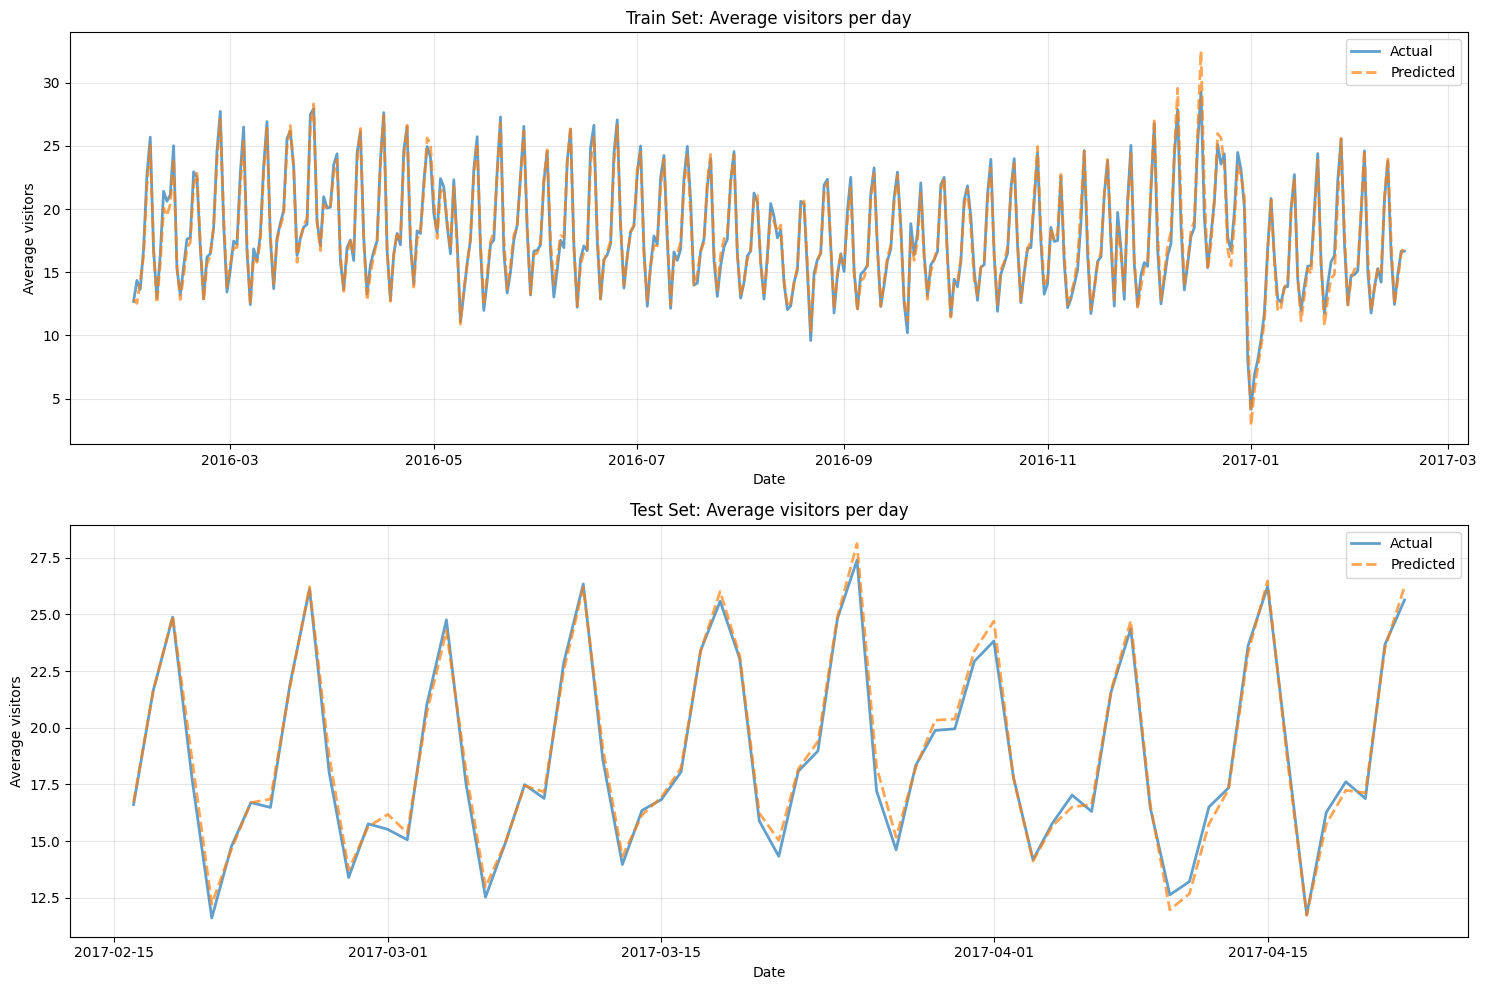

In [20]:
train_daily = merge_daily_pred(train_dates, y_train, y_train_pred)
test_daily = merge_daily_pred(test_dates, y_test, y_test_pred)

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

plot_daily_pred(train_daily, axes[0], train=True)
plot_daily_pred(test_daily, axes[1], train=False)

plt.tight_layout()
plt.show()